### Nossos objetivos e entendimentos comuns sobre o modelo: Random Forest

O Random Forest é um algoritmo de ensemble, ele combina múltiplas árvores de decisão para produzir uma previsão robusta sobre os dados. Cada árvore é treinada em uma amostra aleatória dos dados e features, com a previsão final é feita por votação majoritária. É o segundo modelo do projeto, escolhido por ser robusto a outliers, não-linearidades e por gerar importância das features, útil para interpretabilidade clínica.

### Bibliotecas e imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from utils_fc_notes import avaliar_modelo, plt_matriz_confusao
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

### Carregamento de dados

Carregamos os quatro arquivos gerados pelo pré-processamento. O treino está balanceado pelo SMOTE (2.725/2.725) e normalizado. Já o teste está com a distribuição real e desbalanceada (682/123) para simular a entrada de dados no modelo.

In [2]:
X_train = pd.read_csv('../data/processed_data/X_train.csv')
X_test  = pd.read_csv('../data/processed_data/X_test.csv')
y_train = pd.read_csv('../data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print()
print('Distribuição y_test (dados reais):')
print(y_test.value_counts())
print('  0 = Alive | 1 = Dead')

X_train: (5450, 14) | y_train: (5450,)
X_test:  (805, 14)  | y_test:  (805,)

Distribuição y_test (dados reais):
Status
0    682
1    123
Name: count, dtype: int64
  0 = Alive | 1 = Dead


### Treinamento do modelo
O Random Forest é instanciado com 100 árvores (por entendimento comum é uma quantidade equilibrada e ps: meu custo computacional agradece) e random_state=42 para reprodutibilidade. O n_jobs=-1 usa todos os núcleos disponíveis para treinar em paralelo, acelerando o processo. O modelo aprende os padrões dos dados de treino e gera previsões no teste como desejamos.


In [3]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f'Número de árvores: {rf.n_estimators}')
print(f'Features utilizadas: {rf.n_features_in_}')

Número de árvores: 100
Features utilizadas: 14


### Metricas
Avaliamos o modelo com Acurácia, Precisão, Recall, F1-Score e AUC-ROC, as mesmas métricas do baseline para comparação direta. O classification_report detalha as métricas separadamente para cada classe dos dados (Alive e Dead).

In [4]:
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.793789
Precisão,0.325203
Recall,0.325203
F1-score,0.325203
AUC-ROC,0.601751


In [5]:
print(classification_report(y_test, y_pred, target_names=['Alive (0)', 'Dead (1)'], zero_division=0))

              precision    recall  f1-score   support

   Alive (0)       0.88      0.88      0.88       682
    Dead (1)       0.33      0.33      0.33       123

    accuracy                           0.79       805
   macro avg       0.60      0.60      0.60       805
weighted avg       0.79      0.79      0.79       805



### Matriz de confusão
Visualiza a distribuição das previsões, especialmente os Falsos Negativos (Dead previsto como Alive), que representam o pior cenário clínico, que seria um paciente em risco não identificado pelo modelo.

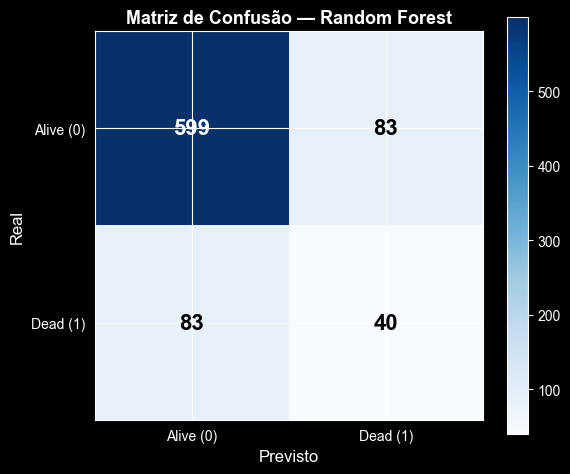


Verdadeiros Negativos: 599
Falsos Positivos: 83
Falsos Negativos: 83
Verdadeiros Positivos: 40


In [6]:
plt_matriz_confusao(
    y_test,
    y_pred,
    nome_modelo='Random Forest',
    salvar=True,
    caminho='../assets/charts_images/distributions/cm_random_forest.png'
)

### Features Importantes

O Random Forest calcula a importância de cada feature com base em quanto ela contribui para reduzir a impureza nas divisões das árvores. As mais importantes foram Reginol_Node_Positive, Tumor_Size, Age e Regional_Node_Examined, um lado positivo que podemos pontuar pois mostra que está alinhado com os insights da EDA.

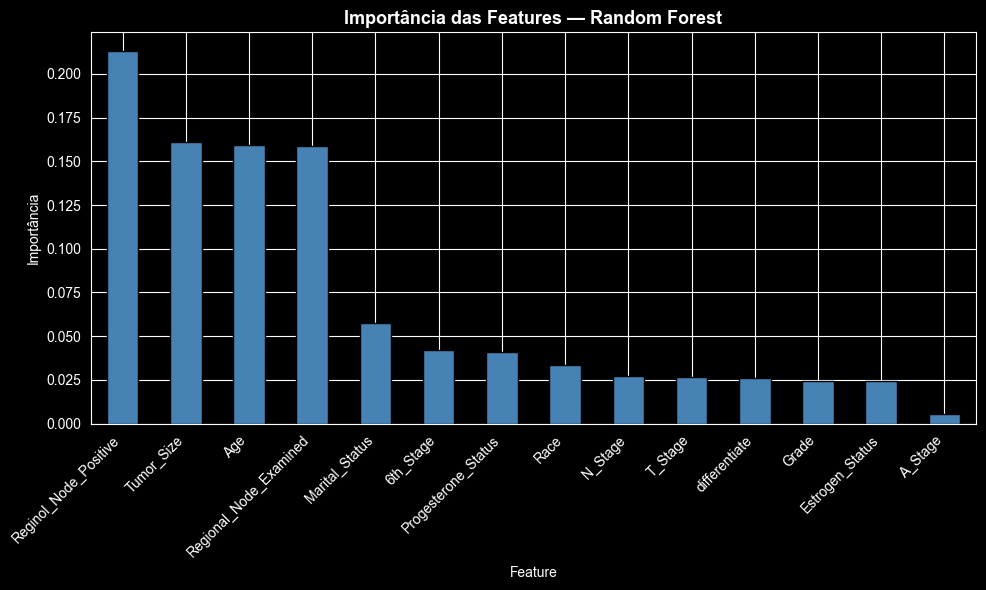


Importância por feature:
Reginol_Node_Positive     0.2131
Tumor_Size                0.1613
Age                       0.1590
Regional_Node_Examined    0.1589
Marital_Status            0.0577
6th_Stage                 0.0418
Progesterone_Status       0.0408
Race                      0.0335
N_Stage                   0.0273
T_Stage                   0.0264
differentiate             0.0262
Grade                     0.0243
Estrogen_Status           0.0242
A_Stage                   0.0055


In [7]:
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Importância das Features — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Importância')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../assets/charts_images/distributions/feature_importance_randomforest.png', dpi=150)
plt.show()

print('\nImportância por feature:')
print(fi.round(4).to_string())

### Hiperparametros

Utilizamos GridSearchCV para buscar a melhor combinação de hiperparâmetros (n_estimators, max_depth, min_samples_split, min_samples_leaf). O grid foi reduzido por limitações computacionais para 32 combinações × 5 folds = 160 treinamentos (foi realizado um teste anterior com 3 × 8 × 3 × 3 = 216 combinações de hiperparâmetros, cada uma treinada 5 vezes (cv=5) = 1.080 treinamentos no total mas o meu computador não aguentou o processo). O scoring='recall' prioriza a detecção de Dead. O resultado confirmou que os parâmetros padrão (max_depth=None, n_estimators=100) já eram os melhores para esse dataset.

In [9]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='recall',   #recall, quero maximizar detecção de Dead
    n_jobs=-1,
    pre_dispatch='2*n_jobs'
)

grid.fit(X_train, y_train)

print('Melhores parâmetros:', grid.best_params_)
print('Melhor Recall (CV):', grid.best_score_.round(4))

rf_best = grid.best_estimator_
y_pred = rf_best.predict(X_test)

Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor Recall (CV): 0.8987


In [10]:
y_pred = grid.best_estimator_.predict(X_test)
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.793789
Precisão,0.325203
Recall,0.325203
F1-score,0.325203
AUC-ROC,0.601751


### Salvamento do modelo

O melhor modelo encontrado pelo GridSearch é serializado com joblib em models/random_forest.joblib. Esse arquivo será carregado pelo backend FastAPI para fazer previsões em produção sem precisar retreinar.

In [11]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_best, '../models/random_forest.joblib')

['../models/random_forest.joblib']